In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

INTERNSHIP_DIR = Path("/home/siddiqun/Bureau/Internship")

# Parent directory containing the conformal_envelopes package.
LIBRARY_PARENT = INTERNSHIP_DIR / "Conformal Library"
if str(LIBRARY_PARENT) not in sys.path:
    sys.path.insert(0, str(LIBRARY_PARENT))

from conformal_envelopes import (ConformalSetModel, evaluate_prediction_sets,)

DATA_DIR = INTERNSHIP_DIR / "Data"
SCORES_PATH = DATA_DIR / "phage_host_scores.parquet"
METADATA_PATH = DATA_DIR / "metadata.csv"

GRAM_PRED_PATH = (INTERNSHIP_DIR / "Codes" / "gram_type_predictions.csv")

ALPHA = 0.10
SEED = 42

print("Library imported successfully.")

for path in [SCORES_PATH, METADATA_PATH, GRAM_PRED_PATH]:
    print(f"{path} — exists: {path.is_file()}")
    assert path.is_file(), f"File not found: {path}"

Library imported successfully.
/home/siddiqun/Bureau/Internship/Data/phage_host_scores.parquet — exists: True
/home/siddiqun/Bureau/Internship/Data/metadata.csv — exists: True
/home/siddiqun/Bureau/Internship/Codes/gram_type_predictions.csv — exists: True


## Load scores and metadata

In [2]:
phage_scores = pd.read_parquet(SCORES_PATH)
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")

print("Scores shape:", phage_scores.shape)
print("Scores index name:", phage_scores.index.name)
print("Scores index is unique:", phage_scores.index.is_unique)
display(phage_scores.head(3))

print("\nMetadata shape:", meta_df.shape)
print("Metadata columns:", meta_df.columns.tolist())
display(meta_df.head(3))

Scores shape: (18443, 2036)
Scores index name: accession
Scores index is unique: True


,Campylobacter_DNA-associated,Campylobacter_DNA_polymerase,Campylobacter_RNA-associated,Campylobacter_adsorption-related,Campylobacter_annealing,Campylobacter_anti-restriction,Campylobacter_baseplate,Campylobacter_capsid,Campylobacter_cell_wall_depolymerase,Campylobacter_ejection,...,Yersinia_tail,Yersinia_tail_appendage,Yersinia_tail_sheath,Yersinia_terminase,Yersinia_toxin,Yersinia_transcriptional_activator,Yersinia_transcriptional_regulator,Yersinia_transcriptional_repressor,Yersinia_transferase,Yersinia_val
accession,,,,,,,,,,,,,,,,,,,,,
AB002632,0.009630,NaN,NaN,NaN,NaN,NaN,NaN,0.010451,NaN,NaN,...,NaN,NaN,NaN,NaN,0.009864,NaN,0.001164,0.001429,NaN,NaN
AB008550,0.000945,NaN,NaN,0.000533,NaN,0.000509,0.001716,0.111331,0.000244,NaN,...,0.201554,0.22153,0.335059,0.348714,0.006572,0.097914,0.122020,NaN,0.013707,NaN
AB009866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Metadata shape: (1853074, 8)
Metadata columns: ['pc', 'accession', 'vc', 'host', 'host_type', 'phrogs_annotation', 'phrogs_category', 'split']


,pc,accession,vc,host,host_type,phrogs_annotation,phrogs_category,split
proteinID,,,,,,,,
AB002632_00001,KP972568_00002,AB002632,VC_0_0,Vibrio,gram-neg,nicking at origin of replication,"DNA, RNA and nucleotide metabolism",0
AB002632_00002,OP297622_00003,AB002632,VC_0_0,Vibrio,gram-neg,single strand DNA binding protein,"DNA, RNA and nucleotide metabolism",0
AB002632_00003,KC357596_00003,AB002632,VC_0_0,Vibrio,gram-neg,minor coat protein,head and packaging,0


#### Joining metadata at phage level

In [3]:
# Collapse protein metadata to one record per phage.
metadata_columns = ["host", "host_type", "split"]
grouped = meta_df.groupby("accession")[metadata_columns]

# Avoid silently selecting conflicting metadata.
conflicts = grouped.nunique().gt(1).any(axis=1)
assert not conflicts.any(), (f"Conflicting metadata for: " f"{conflicts[conflicts].index[:10].tolist()}")

phage_meta = grouped.first()

score_cols = phage_scores.columns.tolist()
all_hosts = sorted({col.split("_", 1)[0] for col in score_cols})

phage_df = phage_scores.join(phage_meta, how="inner", validate="one_to_one",)

assert phage_df[["host", "split"]].notna().all().all()

# Keep hosts represented by the predictor columns.
phage_df = phage_df.loc[phage_df["host"].isin(all_hosts)].copy()
phage_df["split"] = phage_df["split"].astype(int)
phage_df = phage_df.rename_axis("ID").reset_index()

# Preserve the original partition.
train = phage_df.loc[~phage_df["split"].isin([0, 1])].copy()
validation = phage_df.loc[phage_df["split"].eq(1)].copy()
test = phage_df.loc[phage_df["split"].eq(0)].copy()

print("Training phages:", len(train))
print("Validation phages:", len(validation))
print("Test phages:", len(test))
print("Candidate hosts:", len(all_hosts))

Training phages: 9101
Validation phages: 2593
Test phages: 3944
Candidate hosts: 54


## Define each host’s score columns

In [4]:
train_counts = train["host"].value_counts()

fitted_hosts = [host for host in all_hosts if train_counts.get(host, 0) >= 3]

skipped_hosts = sorted(set(all_hosts) - set(fitted_hosts))

label_to_columns = {host: [col for col in score_cols if col.split("_", 1)[0] == host]
                    for host in fitted_hosts}

fit_train = train.loc[train["host"].isin(fitted_hosts)].copy()

# Check that every training phage has a score for its true host.
missing_true_host = 0

for host, columns in label_to_columns.items():
    assert columns, f"No score columns for {host}"

    host_scores = fit_train.loc[fit_train["host"].eq(host), columns]
    missing_true_host += int(host_scores.isna().all(axis=1).sum())

print("Hosts eligible for fitting:", len(fitted_hosts))
print("Skipped hosts:", skipped_hosts)
print("Training rows retained:", len(fit_train))
print("Training phages without true-host scores:", missing_true_host)

assert missing_true_host == 0, "Some training rows lack true-host scores."

Hosts eligible for fitting: 54
Skipped hosts: []
Training rows retained: 9101
Training phages without true-host scores: 0


### Loading the Gram predictions

In [5]:
gram_pred_df = pd.read_csv(GRAM_PRED_PATH).set_index("accession")

assert gram_pred_df.index.is_unique, "Duplicate accession IDs."

# Convert CSV values explicitly to booleans.
for column in ["pred_gramneg", "pred_grampos"]:
    gram_pred_df[column] = (gram_pred_df[column].astype(str).str.strip().str.lower()
                            .map({"true": True, "false": False, "1": True, "0": False,}))

    assert gram_pred_df[column].notna().all(), (f"Invalid or missing values in {column}")

validation_covered = validation["ID"].isin(gram_pred_df.index)

print("Gram prediction file:", GRAM_PRED_PATH)
print("Phages in export:", len(gram_pred_df))
print("Validation IDs covered:", int(validation_covered.sum()))

display(gram_pred_df[["pred_gramneg", "pred_grampos"]].value_counts().rename("phages"))

assert validation_covered.all(), ("Some validation IDs are missing from the Gram prediction file.")

Gram prediction file: /home/siddiqun/Bureau/Internship/Codes/gram_type_predictions.csv
Phages in export: 18474
Validation IDs covered: 2593


pred_gramneg  pred_grampos
True          False           10744
False         True             7730
Name: phages, dtype: int64

#### Constructing candidates from the predicted Gram types and checking whether those candidates have usable scores.

In [6]:
# Map candidate hosts to their Gram group.
host_types = (phage_df[["host", "host_type"]].dropna().drop_duplicates())

assert host_types.groupby("host")["host_type"].nunique().le(1).all()

host_to_gram = host_types.set_index("host")["host_type"].to_dict()

assert all(host_to_gram.get(host) in {"gram-neg", "gram-pos"} for host in fitted_hosts)

# Select candidates using predicted Gram types.
validation_candidates = {}

for sample_id in validation["ID"]:
    prediction = gram_pred_df.loc[sample_id]

    allowed = [host for host in fitted_hosts if (host_to_gram[host] == "gram-neg"
                                                 and prediction["pred_gramneg"]) 
               or (host_to_gram[host] == "gram-pos" and prediction["pred_grampos"])]

    # Match the original notebook's fallback.
    validation_candidates[sample_id] = allowed or fitted_hosts.copy()

# Check availability using columns the collapsed model would retain.
missing_pairs = 0
affected_ids = set()

for host, columns in label_to_columns.items():
    training_scores = fit_train.loc[fit_train["host"].eq(host), columns]
    used_columns = training_scores.columns[training_scores.notna().any(axis=0)].tolist()

    allowed_mask = validation["ID"].map(lambda sample_id: host in validation_candidates[sample_id])
    missing_mask = validation[used_columns].isna().all(axis=1)
    problematic = allowed_mask & missing_mask

    missing_pairs += int(problematic.sum())
    affected_ids.update(validation.loc[problematic, "ID"])

print("Candidate lists created:", len(validation_candidates))
print("Allowed phage–host pairs without scores:", missing_pairs)
print("Validation phages affected:", len(affected_ids))

Candidate lists created: 2593
Allowed phage–host pairs without scores: 32
Validation phages affected: 2


## Collapsed Model

In [7]:
collapsed_model = ConformalSetModel(method="collapsed", alpha=ALPHA, score_direction="higher_is_better",
                                    shape_fraction=0.5, random_state=SEED, force_nonempty=False,)

collapsed_model.fit(fit_train, id_col="ID", label_col="host", score_cols=score_cols, 
                    label_to_columns=label_to_columns,)

envelopes = collapsed_model.get_envelopes()

print("Collapsed envelopes fitted:", len(envelopes))
print("Infinite calibration thresholds:", sum(np.isposinf(info["envelope"]["t_hat"])
                                              for info in envelopes.values()),)

Collapsed envelopes fitted: 54
Infinite calibration thresholds: 12


#### Predicting on validation data

In [8]:
collapsed_predictions = collapsed_model.predict_per_sample(validation,
                                                           candidates_by_id=validation_candidates,)

# Align true labels with prediction IDs.
true_labels = (validation.set_index("ID")["host"].loc[collapsed_predictions["ID"]].tolist())

collapsed_metrics = evaluate_prediction_sets(collapsed_predictions["prediction_set"], true_labels,)

print("Validation predictions:", len(collapsed_predictions))
print(f"Coverage: {collapsed_metrics['coverage']:.3f}")
print(f"Average set size: {collapsed_metrics['average_set_size']:.2f}")
print(f"Singleton rate: {collapsed_metrics['singleton_rate']:.3f}")
print(f"Empty-set rate: {collapsed_metrics['empty_rate']:.3f}")
print("Forced predictions:", int(collapsed_predictions["forced"].sum()))

display(collapsed_predictions[["ID", "prediction_set", "set_size", "forced"]].head())

Validation predictions: 2593
Coverage: 0.872
Average set size: 11.30
Singleton rate: 0.000
Empty-set rate: 0.001
Forced predictions: 0


,ID,prediction_set,set_size,forced
0,AB008550,"[Citrobacter, Cronobacter, Dickeya, Edwardsiel...",18,False
1,AB009866,"[Clostridioides, Enterococcus, Lacticaseibacil...",5,False
2,AB044554,"[Clostridioides, Enterococcus, Lacticaseibacil...",4,False
3,AB243556,"[Clostridioides, Enterococcus, Lacticaseibacil...",5,False
4,AB362338,"[Cronobacter, Dickeya, Edwardsiella, Enterobac...",18,False


## Radial Envelope

In [9]:
radial_model = ConformalSetModel(method="radial", alpha=ALPHA, score_direction="higher_is_better", 
                                 shape_fraction=0.5, random_state=SEED, force_nonempty=False, 
                                 n_directions=100, smoothing=4.0, angle_deg=30.0, neighbor_fraction=0.2,)

radial_model.fit(fit_train, id_col="ID", label_col="host", score_cols=score_cols, label_to_columns=label_to_columns,)

radial_envelopes = radial_model.get_envelopes()

print("Radial envelopes fitted:", len(radial_envelopes))
print("Infinite calibration thresholds:", sum(np.isposinf(info["envelope"]["t_hat"])
                                              for info in radial_envelopes.values()),)

Radial envelopes fitted: 54
Infinite calibration thresholds: 12


In [10]:
radial_predictions = radial_model.predict_per_sample(validation,
                                                     candidates_by_id=validation_candidates,)

radial_true_labels = (validation.set_index("ID")["host"].loc[radial_predictions["ID"]].tolist())

radial_metrics = evaluate_prediction_sets(radial_predictions["prediction_set"], radial_true_labels,)

print("Validation predictions:", len(radial_predictions))
print(f"Coverage: {radial_metrics['coverage']:.3f}")
print(f"Average set size: {radial_metrics['average_set_size']:.2f}")
print(f"Singleton rate: {radial_metrics['singleton_rate']:.3f}")
print(f"Empty-set rate: {radial_metrics['empty_rate']:.3f}")
print("Forced predictions:", int(radial_predictions["forced"].sum()))

Validation predictions: 2593
Coverage: 0.894
Average set size: 16.46
Singleton rate: 0.000
Empty-set rate: 0.000
Forced predictions: 0


## Strip Envelope

In [11]:
strip_model = ConformalSetModel(method="strip", alpha=ALPHA, score_direction="higher_is_better", 
                                shape_fraction=0.5, random_state=SEED, force_nonempty=False, n_bins=10,
                                min_samples=3,)

strip_model.fit(fit_train, id_col="ID", label_col="host", score_cols=score_cols, 
                label_to_columns=label_to_columns,)

strip_envelopes = strip_model.get_envelopes()

print("Strip envelopes fitted:", len(strip_envelopes))
print("Infinite calibration thresholds:",sum(np.isposinf(info["envelope"]["t_hat"])
                                             for info in strip_envelopes.values()),)

Strip envelopes fitted: 54
Infinite calibration thresholds: 12


In [12]:
from time import perf_counter

start = perf_counter()

strip_predictions = strip_model.predict_per_sample(validation, candidates_by_id=validation_candidates,)
strip_prediction_seconds = perf_counter() - start

strip_true_labels = (validation.set_index("ID")["host"].loc[strip_predictions["ID"]].tolist())

strip_metrics = evaluate_prediction_sets(strip_predictions["prediction_set"], strip_true_labels,)

print(f"Prediction time: {strip_prediction_seconds:.1f} seconds")
print("Validation predictions:", len(strip_predictions))
print(f"Coverage: {strip_metrics['coverage']:.3f}")
print(f"Average set size: {strip_metrics['average_set_size']:.2f}")
print(f"Singleton rate: {strip_metrics['singleton_rate']:.3f}")
print(f"Empty-set rate: {strip_metrics['empty_rate']:.3f}")
print("Forced predictions:", int(strip_predictions["forced"].sum()))

display(strip_predictions[["ID", "prediction_set", "set_size", "forced"]].head())

Prediction time: 6.5 seconds
Validation predictions: 2593
Coverage: 0.755
Average set size: 12.91
Singleton rate: 0.000
Empty-set rate: 0.000
Forced predictions: 0


,ID,prediction_set,set_size,forced
0,AB008550,"[Citrobacter, Cronobacter, Dickeya, Edwardsiel...",25,False
1,AB009866,"[Clostridioides, Lacticaseibacillus, Staphyloc...",3,False
2,AB044554,"[Clostridioides, Lacticaseibacillus, Staphyloc...",3,False
3,AB243556,"[Clostridioides, Lacticaseibacillus, Staphyloc...",3,False
4,AB362338,"[Cronobacter, Dickeya, Edwardsiella, Enterobac...",17,False


# Example

In [13]:
import pandas as pd

import matplotlib.pyplot as plt

from conformal_envelopes import ConformalSetModel

from conformal_envelopes import evaluate_prediction_sets

train = pd.read_csv("train_example.csv")
test = pd.read_csv("test_example.csv")

print(train.head())
print()
print(test.head())

        ID   score_1   score_2   score_3 label
0  id_0000  0.373086  0.330935  0.558781     B
1  id_0001  0.465200  0.284044  0.493325     B
2  id_0002  0.889371  0.661489  0.821468     A
3  id_0003  0.959575  0.732291  0.904879     A
4  id_0004  0.355465  0.302119  0.324708     B

        ID   score_1   score_2   score_3 label
0  id_0200  0.309090       NaN  0.390388     B
1  id_0201  0.895580  0.765823  0.817216     A
2  id_0202       NaN  0.444927  0.463014     B
3  id_0203       NaN  0.486706  0.429451     B
4  id_0204  0.306971  0.234696       NaN     B


{'A': {'label': 'A', 'method': 'strip', 'columns': ['score_1', 'score_2', 'score_3'], 'alpha': 0.1, 'shape_size': 49, 'calibration_size': 50, 'parameters': {}, 'idx_s1': array([ 1, 74, 53, 64, 80, 17, 29, 25, 49, 68, 84, 61, 33, 54, 44, 37, 86,
       45, 72, 96, 38, 23, 22, 90, 52, 65, 59, 36, 92, 55, 94, 13, 89, 63,
       30, 77, 97, 70, 32, 28,  6, 79, 83, 34,  0,  7, 67, 82, 91]), 'idx_s2': array([20, 47, 76, 88, 16, 39,  8, 98, 69, 48, 11, 35, 15, 27, 51, 73, 66,
        3, 14, 78, 87, 81, 10, 58, 46, 24, 12, 42, 50,  2, 43, 41,  5,  4,
       21, 31, 18, 40, 56, 71, 95, 85, 93, 75, 19, 26, 62, 57,  9, 60]), 'envelope': {'method': 'strip', 'bin_edges': array([[0.        , 0.0372534 , 0.0745068 , 0.11176021, 0.14901361,
        0.18626701, 0.22352041, 0.26077382, 0.29802722],
       [0.01976782, 0.06574134, 0.11171487, 0.15768839, 0.20366192,
        0.24963544, 0.29560897, 0.3415825 , 0.38755602],
       [0.0265021 , 0.06929195, 0.11208179, 0.15487164, 0.19766149,
        0.24045

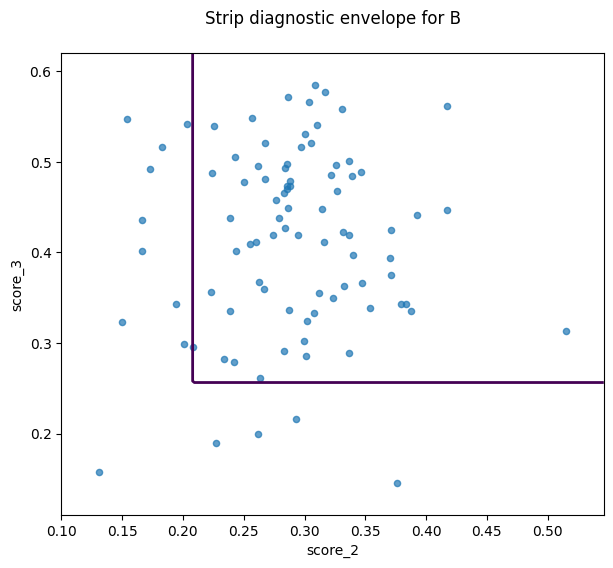

In [14]:
###### STRIP MODEL ######
# creating the model
model = ConformalSetModel(method="strip", alpha=0.1, random_state=13,)

# Fitting the model using training file
# takes the training data, separates the observations by class (A and B), splits each class into S1 and S2, 
# learns the Collapsed envelope shape from S1, and calibrates it using S2.
model.fit(train)

# inspecting the constructed envelopes
print(model.get_envelopes())

# using the learnt envelopes to make the conformal prediction sets for the test data
predictions = model.predict(test)
print(predictions)

# comparing each set with the true label in the test data
results = evaluate_prediction_sets(predictions["prediction_set"], test["label"])
print(results)

# plotting 2D
model.plot(x="score_2", y="score_3", label="B")
plt.show()


{'A': {'label': 'A', 'method': 'radial', 'columns': [np.str_('score_1'), np.str_('score_2'), np.str_('score_3')], 'alpha': 0.1, 'shape_size': 49, 'calibration_size': 50, 'parameters': {}, 'idx_s1': array([ 1, 74, 53, 64, 80, 17, 29, 25, 49, 68, 84, 61, 33, 54, 44, 37, 86,
       45, 72, 96, 38, 23, 22, 90, 52, 65, 59, 36, 92, 55, 94, 13, 89, 63,
       30, 77, 97, 70, 32, 28,  6, 79, 83, 34,  0,  7, 67, 82, 91]), 'idx_s2': array([20, 47, 76, 88, 16, 39,  8, 98, 69, 48, 11, 35, 15, 27, 51, 73, 66,
        3, 14, 78, 87, 81, 10, 58, 46, 24, 12, 42, 50,  2, 43, 41,  5,  4,
       21, 31, 18, 40, 56, 71, 95, 85, 93, 75, 19, 26, 62, 57,  9, 60]), 'envelope': {'method': 'radial', 'U': array([[0.53927929, 0.5584559 , 0.63032124],
       [0.38998718, 0.19274635, 0.90042148],
       [0.50829663, 0.57218175, 0.6436168 ],
       [0.21598809, 0.96272397, 0.16282416],
       [0.72324679, 0.68723123, 0.06802436],
       [0.17309404, 0.98490294, 0.00215787],
       [0.17130164, 0.7534682 , 0.63477667

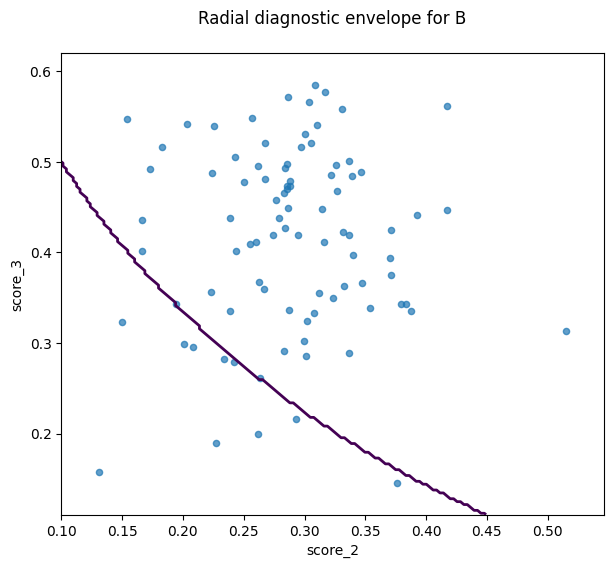

In [15]:
###### RADIAL MODEL ######
# creating the model
model = ConformalSetModel(method="radial", alpha=0.1, random_state=13,)

# Fitting the model using training file
# takes the training data, separates the observations by class (A and B), splits each class into S1 and S2, 
# learns the Collapsed envelope shape from S1, and calibrates it using S2.
model.fit(train)

# inspecting the constructed envelopes
print(model.get_envelopes())

# using the learnt envelopes to make the conformal prediction sets for the test data
predictions = model.predict(test)
print(predictions)

# comparing each set with the true label in the test data
results = evaluate_prediction_sets(predictions["prediction_set"], test["label"])
print(results)

# plotting 2D
model.plot(x="score_2", y="score_3", label="B")
plt.show()

In [16]:
###### COLLAPSED MODEL ######
# creating the model
model = ConformalSetModel(method="collapsed", alpha=0.1, random_state=13)

# Fitting the model using training file
# takes the training data, separates the observations by class (A and B), splits each class into S1 and S2, 
# learns the Collapsed envelope shape from S1, and calibrates it using S2.
model.fit(train)

# inspecting the constructed envelopes
print(model.get_envelopes())

# using the learnt envelopes to make the conformal prediction sets for the test data
predictions = model.predict(test)
print(predictions)

# comparing each set with the true label in the test data
results = evaluate_prediction_sets(predictions["prediction_set"], test["label"])
print(results)

{'A': {'label': 'A', 'method': 'collapsed', 'columns': [np.str_('score_1'), np.str_('score_2'), np.str_('score_3')], 'alpha': 0.1, 'shape_size': 49, 'calibration_size': 50, 'parameters': {}, 'idx_s1': array([ 1, 74, 53, 64, 80, 17, 29, 25, 49, 68, 84, 61, 33, 54, 44, 37, 86,
       45, 72, 96, 38, 23, 22, 90, 52, 65, 59, 36, 92, 55, 94, 13, 89, 63,
       30, 77, 97, 70, 32, 28,  6, 79, 83, 34,  0,  7, 67, 82, 91]), 'idx_s2': array([20, 47, 76, 88, 16, 39,  8, 98, 69, 48, 11, 35, 15, 27, 51, 73, 66,
        3, 14, 78, 87, 81, 10, 58, 46, 24, 12, 42, 50,  2, 43, 41,  5,  4,
       21, 31, 18, 40, 56, 71, 95, 85, 93, 75, 19, 26, 62, 57,  9, 60]), 'envelope': {'method': 'collapsed', 'q_tilde': 0.20891390445897287, 't_hat': 1.1663837756898863}}, 'B': {'label': 'B', 'method': 'collapsed', 'columns': [np.str_('score_1'), np.str_('score_2'), np.str_('score_3')], 'alpha': 0.1, 'shape_size': 50, 'calibration_size': 51, 'parameters': {}, 'idx_s1': array([51, 38,  4, 48,  8,  1, 92, 88, 57, 62, 7

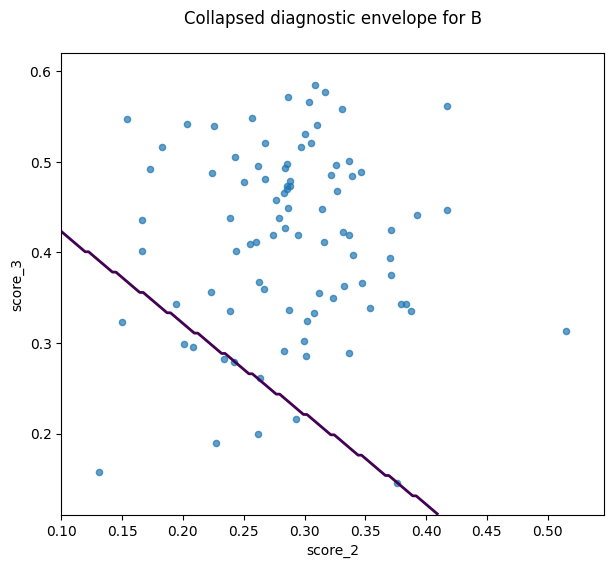

In [17]:
# plotting 2D
model.plot(x="score_2", y="score_3", label="B")
plt.show()